In [ ]:
import pandas as pd
import numpy as np
import random
import re
from collections import Counter
import tensorflow as tf
from tensorflow.keras import layers, Input
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow import keras
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import EarlyStopping
from gensim.models import Word2Vec
from sklearn.preprocessing import normalize
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

# Set seeds for reproducibility
random.seed(416)
np.random.seed(416)
tf.random.set_seed(416)


In [3]:
file_patient_report = r"C:\Users\jwang\Documents\PQHS416\Final project\pqhs416_2025.csv"
file_ontology_mapping = (
    r"C:\Users\jwang\Documents\PQHS416\Final project\input_modified.csv"
)

df = pd.read_csv(file_ontology_mapping)

#summarize data in each column
def summarize_column(col):
    if pd.api.types.is_numeric_dtype(col):
        return f"{col.min()} to {col.max()}"
    else:
        unique_count = col.dropna().nunique()
        return f"{unique_count} unique values"

summary = pd.DataFrame(
    {
        "Feature Name": df.columns,
        "Data Type": df.dtypes.values,
        "Value Range or Unique Count": [
            summarize_column(df[col]) for col in df.columns
        ],
        "Non-Missing Count": df.notnull().sum().values,
        "Missing Value Count": df.isnull().sum().values,
        "Zero Value Count": (df == "0").sum().values,
    }
)

print(summary)

# summary.to_csv(
#     r"C:\Users\jwang\Documents\PQHS416\Final project\origianl_data_summary_table.csv",
#     index=False,
# )

           Feature Name Data Type Value Range or Unique Count  \
0                    ID     int64                    2 to 315   
1                   MRI    object            84 unique values   
2            Microscopy    object           175 unique values   
3  Immunohistochemistry    object           130 unique values   
4          Localization    object            96 unique values   
5             Diagnosis    object            12 unique values   

   Non-Missing Count  Missing Value Count  Zero Value Count  
0                178                    0                 0  
1                 96                   82                 0  
2                178                    0                 0  
3                173                    5                 0  
4                170                    8                 0  
5                178                    0                 0  


In [4]:
# Compare the unique terms before and after ontology-based mapping
def count_unique_terms(file_path, column_name):
    df = pd.read_csv(file_path)
    # df = df.replace(to_replace=["0", 0], value="")
    df[column_name] = df[column_name].fillna("").astype(str).str.title()

    # df[column_name] = df[column_name].fillna("").astype(str).str.lower()
    # df[column_name] = df[column_name].apply(lambda x: re.sub(r"\([^)]*\)", "", x))

    all_terms = []
    for row in df[column_name]:
        if row:
            terms = [term.strip() for term in row.split(",")]
            all_terms.extend(terms)

    term_counts = Counter(all_terms)
    return len(term_counts)

# Columns to analyze
columns_to_analyze = [
    "MRI",
    "Microscopy",
    "Immunohistochemistry",
    "Localization",
    "Diagnosis",
]

# Count unique terms in both files
original_counts = {
    column: count_unique_terms(file_patient_report, column)
    for column in columns_to_analyze
}
mapped_counts = {
    column: count_unique_terms(file_ontology_mapping, column)
    for column in columns_to_analyze
}

# Calculate decrease percentage
decrease_percentage = {
    column: (
        (original_counts[column] - mapped_counts[column]) / original_counts[column]
    )
    * 100
    for column in columns_to_analyze
}

# Create comparison table
comparison_table = pd.DataFrame(
    {
        "Original numbers of terms in patient report": original_counts,
        "Number of terms after ontology mapping": mapped_counts,
        "Decrease in the number of terms (in %)": decrease_percentage,
    }
)

print(comparison_table)

# comparison_table.to_csv(
#     r"C:\Users\jwang\Documents\PQHS416\Final project\mapping_summary.csv",
#     index=False,
# )

                      Original numbers of terms in patient report  \
MRI                                                           135   
Microscopy                                                    525   
Immunohistochemistry                                           89   
Localization                                                  100   
Diagnosis                                                      12   

                      Number of terms after ontology mapping  \
MRI                                                      109   
Microscopy                                               470   
Immunohistochemistry                                      67   
Localization                                              94   
Diagnosis                                                 12   

                      Decrease in the number of terms (in %)  
MRI                                                19.259259  
Microscopy                                         10.476190  
Immunohisto

# Build a customized keras functional API

#### Use the data after ontology-based mapping processing

In [5]:
# Load and preprocess data
data = pd.read_csv(
    r"C:\Users\jwang\Documents\PQHS416\Final project\input_modified.csv"
)
data = data.map(str)
data = data.replace("0", "unknown")
data = data.map(lambda x: re.sub(r"[^\w\s]", "", x))
data = data.map(lambda x: x.lower() if isinstance(x, str) else x)

# Shuffle the data
shuffled_data = data.sample(frac=1, random_state=416).reset_index(drop=True)
X = shuffled_data.drop(columns=["Diagnosis"])
y = shuffled_data["Diagnosis"]

# Split the data into training set (70%) and testing set (30%)
train_size = int(0.7 * len(shuffled_data))
X_train = X[:train_size]
X_test = X[train_size:]
y_train = y[:train_size]
y_test = y[train_size:]


In [6]:
# One-hot encode the Diagnosis column
y_train_encoded = y_train.astype("category").cat.codes
y_test_encoded = y_test.astype("category").cat.codes
y_one_hot_train = to_categorical(y_train_encoded, num_classes=y_train.nunique())
y_one_hot_test = to_categorical(y_test_encoded, num_classes=y_train.nunique())


In [7]:
# Function to extract word2vec embeddings
def get_word2vec_embeddings(data, column, model):
    embeddings = []
    for text in data[column]:
        words = text.split()
        word_embeddings = [model.wv[word] for word in words if word in model.wv]
        if word_embeddings:
            embeddings.append(np.mean(word_embeddings, axis=0))
        else:
            embeddings.append(np.zeros(model.vector_size))
    embeddings = np.array(embeddings)
    return normalize(embeddings, axis=1)

# Word2Vec training on training set
mri_model = Word2Vec(
    X_train["MRI"].apply(lambda x: x.split()), min_count=1, vector_size=100
)
loc_model = Word2Vec(
    X_train["Localization"].apply(lambda x: x.split()), min_count=1, vector_size=100
)

# Generate embeddings
mri_train_embeddings = get_word2vec_embeddings(X_train, "MRI", mri_model)
mri_test_embeddings = get_word2vec_embeddings(X_test, "MRI", mri_model)
loc_train_embeddings = get_word2vec_embeddings(X_train, "Localization", loc_model)
loc_test_embeddings = get_word2vec_embeddings(X_test, "Localization", loc_model)


In [8]:
# Multi-hot encoding
def multi_hot_encode(data, column, tokenizer=None):
    if tokenizer is None:
        tokenizer = Tokenizer(lower=True)
        tokenizer.fit_on_texts(data[column].tolist())
    multi_hot = tokenizer.texts_to_matrix(data[column].tolist(), mode="binary")
    return multi_hot, tokenizer


microscopy_train_multi_hot, microscopy_tokenizer = multi_hot_encode(
    X_train, "Microscopy"
)
microscopy_test_multi_hot, _ = multi_hot_encode(
    X_test, "Microscopy", microscopy_tokenizer
)

ihc_train_multi_hot, ihc_tokenizer = multi_hot_encode(X_train, "Immunohistochemistry")
ihc_test_multi_hot, _ = multi_hot_encode(X_test, "Immunohistochemistry", ihc_tokenizer)


In [9]:
# Hyperparameter of the model (different hyperparameters were tested and this model is selected based best test accuracy)
# architectures: "Two-hidden-lalyer": [128, 64], "Three-hidden-layer": [128, 128, 64] - best, "Four-hidden-layer": [128, 128, 128, 64]

activation_function = "leaky_relu"    #"relu", "tanh"
dropout_rate = 0.4    # 0.3, 0.5
optimizer = "RMSprop"     # "Adam", "SGD"

In [10]:
# Model creation function
def create_model():
    mri_input = Input(shape=(100,), name="MRI")
    loc_input = Input(shape=(100,), name="Localization")
    microscopy_input = Input(
        shape=(microscopy_train_multi_hot.shape[1],), name="Microscopy"
    )
    ihc_input = Input(
        shape=(ihc_train_multi_hot.shape[1],), name="Immunohistochemistry"
    )

    mri_features = layers.Dense(128, activation="relu")(mri_input)
    loc_features = layers.Dense(128, activation="relu")(loc_input)

    features = layers.Concatenate()(
        [mri_features, loc_features, microscopy_input, ihc_input]
    )

    features = layers.Dense(128, activation=activation_function)(features)
    features = layers.BatchNormalization()(features)
    features = layers.Dropout(dropout_rate)(features)
    features = layers.Dense(128, activation=activation_function)(features)
    features = layers.BatchNormalization()(features)
    features = layers.Dropout(dropout_rate)(features)
    features = layers.Dense(64, activation=activation_function)(features)
    features = layers.BatchNormalization()(features)
    features = layers.Dropout(dropout_rate)(features)

    output = layers.Dense(
        y_one_hot_train.shape[1], activation="softmax", name="Diagnosis"
    )(features)

    model = keras.Model(
        inputs=[mri_input, loc_input, microscopy_input, ihc_input], outputs=output
    )
    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


c:\Users\jwang\miniconda3\envs\myenv\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(



----- Fold 1 -----


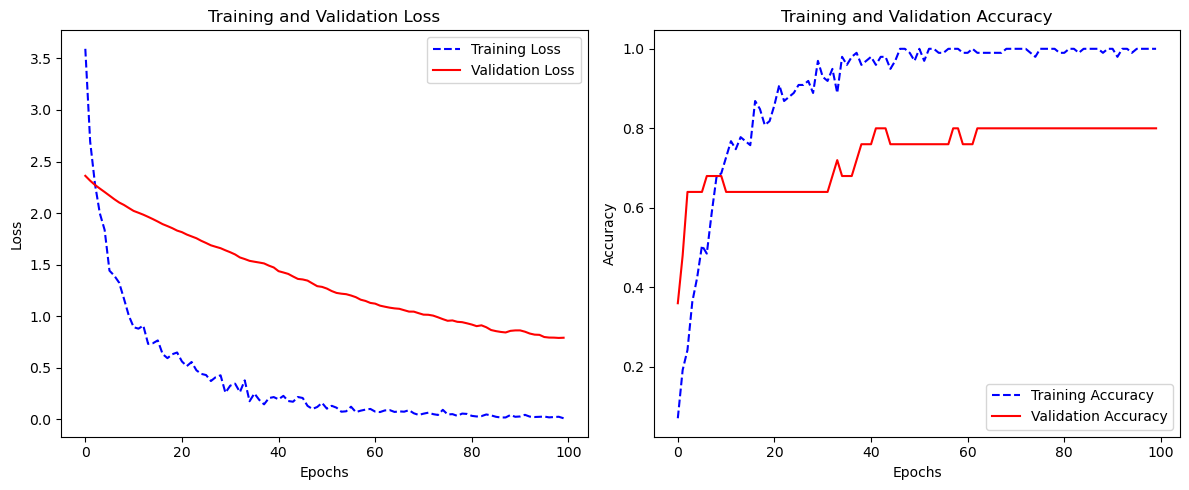


----- Fold 2 -----


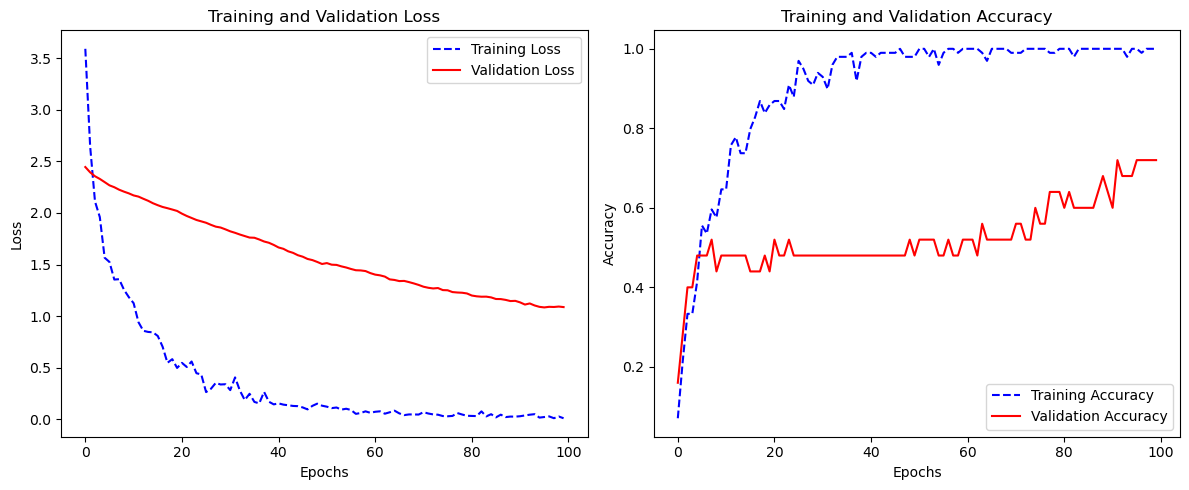


----- Fold 3 -----


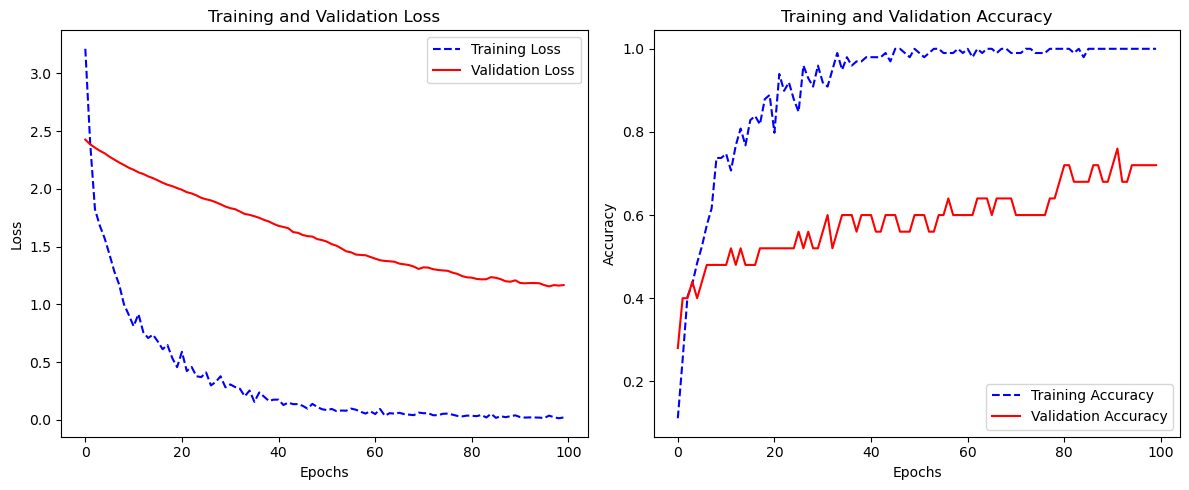


----- Fold 4 -----


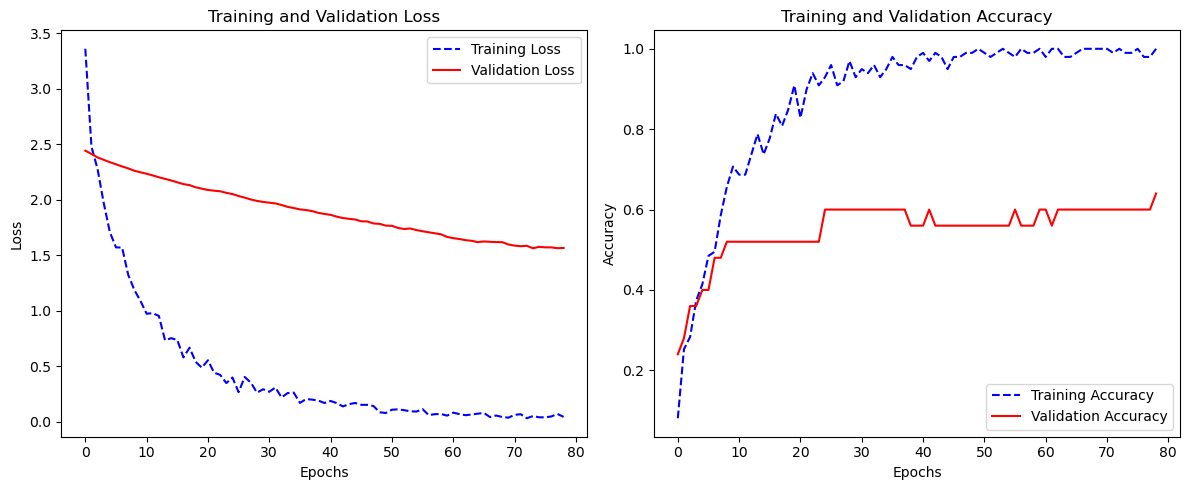


----- Fold 5 -----


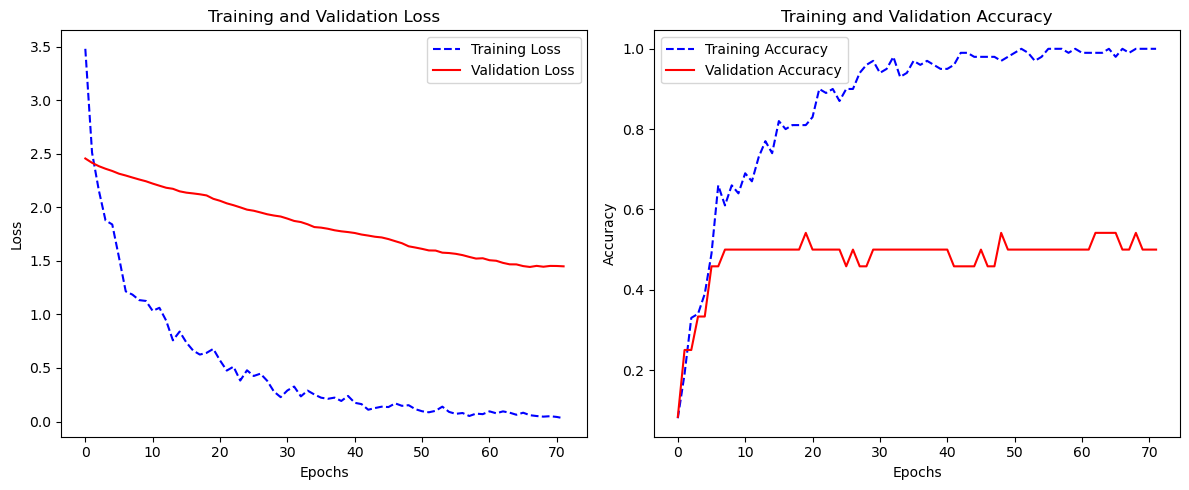

In [16]:
# Cross-validation
val_accuracies = []
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=416)
best_val_accuracy = 0
best_weights = None

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train, y_train_encoded)):
    print(f"\n----- Fold {fold + 1} -----")

    mri_fold_train = mri_train_embeddings[train_idx]
    mri_fold_val = mri_train_embeddings[val_idx]
    loc_fold_train = loc_train_embeddings[train_idx]
    loc_fold_val = loc_train_embeddings[val_idx]
    microscopy_fold_train = microscopy_train_multi_hot[train_idx]
    microscopy_fold_val = microscopy_train_multi_hot[val_idx]
    ihc_fold_train = ihc_train_multi_hot[train_idx]
    ihc_fold_val = ihc_train_multi_hot[val_idx]
    y_fold_train = y_one_hot_train[train_idx]
    y_fold_val = y_one_hot_train[val_idx]

    model = create_model()
    early_stopping = EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True
    )

    history = model.fit(
        [mri_fold_train, loc_fold_train, microscopy_fold_train, ihc_fold_train],
        y_fold_train,
        epochs=100,
        batch_size=64,
        validation_data=(
            [mri_fold_val, loc_fold_val, microscopy_fold_val, ihc_fold_val],
            y_fold_val,
        ),
        callbacks=[early_stopping],
        verbose=0,
    )

    val_accuracy = history.history["val_accuracy"][-1]
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_weights = model.get_weights()

    # Plot loss
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["loss"], "b--", label="Training Loss")
    plt.plot(history.history["val_loss"], "r-", label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()

    # Plot training and validation accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history["accuracy"], "b--", label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], "r-", label="Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Training and Validation Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()


In [12]:
# Final model training
final_model = create_model()
final_model.set_weights(best_weights)
final_model.fit(
    [
        mri_train_embeddings,
        loc_train_embeddings,
        microscopy_train_multi_hot,
        ihc_train_multi_hot,
    ],
    y_one_hot_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=0,
)


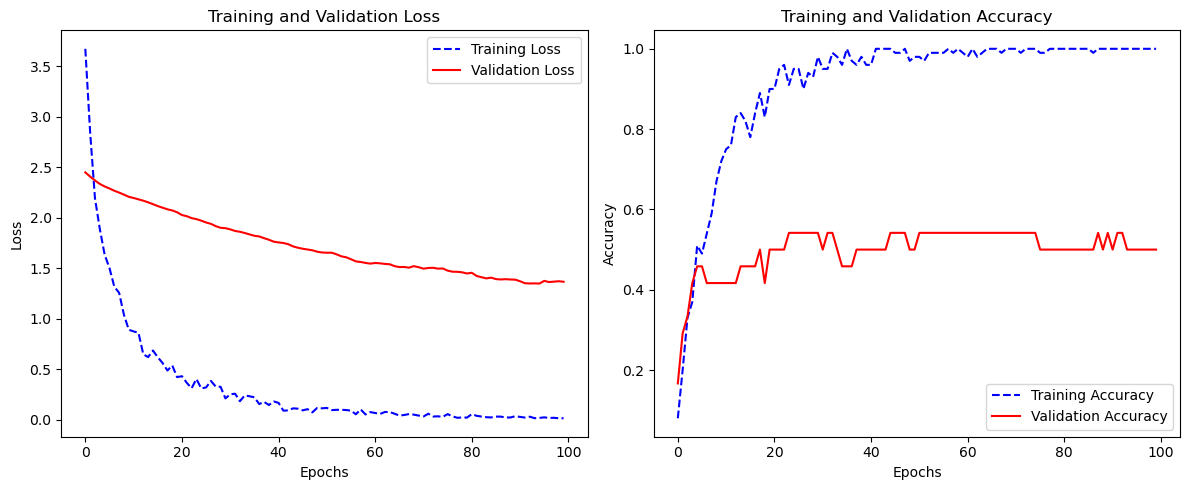

In [13]:
# Plot loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], "b--", label="Training Loss")
plt.plot(history.history["val_loss"], "r-", label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], "b--", label="Training Accuracy")
plt.plot(history.history["val_accuracy"], "r-", label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


In [14]:
# Evaluation
test_loss, test_accuracy = final_model.evaluate(
    [
        mri_test_embeddings,
        loc_test_embeddings,
        microscopy_test_multi_hot,
        ihc_test_multi_hot,
    ],
    y_one_hot_test,
)

print("\n----- Test Results -----")
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7438 - loss: 0.9060

----- Test Results -----
Test Loss: 0.9009011387825012
Test Accuracy: 0.7407407164573669


In [36]:
import os
import sys

# (1) Add Graphviz binary to system path (if not already there)
os.environ["PATH"] += os.pathsep + "C:\\Program Files\\Graphviz\\bin"

# (2) Manually confirm or append the site-packages to sys.path
# You can adjust this path if needed (example shown for Windows + conda)
site_packages_path = r"C:\Users\jwang\miniconda3\envs\myenv\Lib\site-packages"
if site_packages_path not in sys.path:
    sys.path.append(site_packages_path)

# (3) Import and use plot_model
from tensorflow.keras.utils import plot_model

plot_model(
    final_model,
    to_file="customized_API_model.png",
    show_layer_names=True,
    show_shapes=True,
)
plot_model(
    final_model, "model.png", show_layer_names=True, show_shapes=True
)


You must install pydot (`pip install pydot`) for `plot_model` to work.
You must install pydot (`pip install pydot`) for `plot_model` to work.


#### Use the original data in the same model

In [15]:
# Load and preprocess data
random.seed(416)
np.random.seed(416)
tf.random.set_seed(416)
data = pd.read_csv(r"C:\Users\jwang\Documents\PQHS416\Final project\pqhs416_2025.csv")
data = data.map(str)
data = data.replace("0", "unknown")
data = data.map(lambda x: re.sub(r"[^\w\s]", "", x))
data = data.map(lambda x: x.lower() if isinstance(x, str) else x)

# Shuffle the data
shuffled_data = data.sample(frac=1, random_state=416).reset_index(drop=True)
X = shuffled_data.drop(columns=["Diagnosis"])
y = shuffled_data["Diagnosis"]

# Split the data into training set (70%) and testing set (30%)
train_size = int(0.7 * len(shuffled_data))
X_train = X[:train_size]
X_test = X[train_size:]
y_train = y[:train_size]
y_test = y[train_size:]

# Shuffle and split the data
shuffled_data = data.sample(frac=1, random_state=416).reset_index(drop=True)
X = shuffled_data.drop(columns=["Diagnosis"])
y = shuffled_data["Diagnosis"]

train_size = int(0.7 * len(shuffled_data))
X_train = X[:train_size]
X_test = X[train_size:]
y_train = y[:train_size]
y_test = y[train_size:]

# One-hot encode the Diagnosis column
y_train_encoded = y_train.astype("category").cat.codes
y_test_encoded = y_test.astype("category").cat.codes
y_one_hot_train = to_categorical(y_train_encoded, num_classes=y_train.nunique())
y_one_hot_test = to_categorical(y_test_encoded, num_classes=y_train.nunique())


# Function to extract word2vec embeddings
def get_word2vec_embeddings(data, column, model):
    embeddings = []
    for text in data[column]:
        words = text.split()
        word_embeddings = [model.wv[word] for word in words if word in model.wv]
        if word_embeddings:
            embeddings.append(np.mean(word_embeddings, axis=0))
        else:
            embeddings.append(np.zeros(model.vector_size))
    embeddings = np.array(embeddings)
    return normalize(embeddings, axis=1)


# Word2Vec training on training set
mri_model = Word2Vec(
    X_train["MRI"].apply(lambda x: x.split()), min_count=1, vector_size=100
)
loc_model = Word2Vec(
    X_train["Localization"].apply(lambda x: x.split()), min_count=1, vector_size=100
)

# Generate embeddings
mri_train_embeddings = get_word2vec_embeddings(X_train, "MRI", mri_model)
mri_test_embeddings = get_word2vec_embeddings(X_test, "MRI", mri_model)
loc_train_embeddings = get_word2vec_embeddings(X_train, "Localization", loc_model)
loc_test_embeddings = get_word2vec_embeddings(X_test, "Localization", loc_model)


# Multi-hot encoding
def multi_hot_encode(data, column, tokenizer=None):
    if tokenizer is None:
        tokenizer = Tokenizer(lower=True)
        tokenizer.fit_on_texts(data[column].tolist())
    multi_hot = tokenizer.texts_to_matrix(data[column].tolist(), mode="binary")
    return multi_hot, tokenizer


microscopy_train_multi_hot, microscopy_tokenizer = multi_hot_encode(
    X_train, "Microscopy"
)
microscopy_test_multi_hot, _ = multi_hot_encode(
    X_test, "Microscopy", microscopy_tokenizer
)

ihc_train_multi_hot, ihc_tokenizer = multi_hot_encode(X_train, "Immunohistochemistry")
ihc_test_multi_hot, _ = multi_hot_encode(X_test, "Immunohistochemistry", ihc_tokenizer)


# Model creation function
def create_model():
    mri_input = Input(shape=(100,), name="MRI")
    loc_input = Input(shape=(100,), name="Localization")
    microscopy_input = Input(
        shape=(microscopy_train_multi_hot.shape[1],), name="Microscopy"
    )
    ihc_input = Input(
        shape=(ihc_train_multi_hot.shape[1],), name="Immunohistochemistry"
    )

    mri_features = layers.Dense(128, activation="relu")(mri_input)
    loc_features = layers.Dense(128, activation="relu")(loc_input)

    features = layers.Concatenate()(
        [mri_features, loc_features, microscopy_input, ihc_input]
    )

    features = layers.Dense(128, activation="leaky_relu")(features)
    features = layers.BatchNormalization()(features)
    features = layers.Dropout(0.3)(features)
    features = layers.Dense(128, activation="leaky_relu")(features)
    features = layers.BatchNormalization()(features)
    features = layers.Dropout(0.3)(features)
    features = layers.Dense(64, activation="leaky_relu")(features)
    features = layers.BatchNormalization()(features)
    features = layers.Dropout(0.3)(features)

    output = layers.Dense(
        y_one_hot_train.shape[1], activation="softmax", name="Diagnosis"
    )(features)

    model = keras.Model(
        inputs=[mri_input, loc_input, microscopy_input, ihc_input], outputs=output
    )
    model.compile(
        optimizer="RMSprop",
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


# Cross-validation
val_accuracies = []
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=416)
best_val_accuracy = 0
best_weights = None

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train, y_train_encoded)):
    print(f"\n----- Fold {fold + 1} -----")

    mri_fold_train = mri_train_embeddings[train_idx]
    mri_fold_val = mri_train_embeddings[val_idx]
    loc_fold_train = loc_train_embeddings[train_idx]
    loc_fold_val = loc_train_embeddings[val_idx]
    microscopy_fold_train = microscopy_train_multi_hot[train_idx]
    microscopy_fold_val = microscopy_train_multi_hot[val_idx]
    ihc_fold_train = ihc_train_multi_hot[train_idx]
    ihc_fold_val = ihc_train_multi_hot[val_idx]
    y_fold_train = y_one_hot_train[train_idx]
    y_fold_val = y_one_hot_train[val_idx]

    model = create_model()
    early_stopping = EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True
    )

    history = model.fit(
        [mri_fold_train, loc_fold_train, microscopy_fold_train, ihc_fold_train],
        y_fold_train,
        epochs=100,
        batch_size=64,
        validation_data=(
            [mri_fold_val, loc_fold_val, microscopy_fold_val, ihc_fold_val],
            y_fold_val,
        ),
        callbacks=[early_stopping],
        verbose=0,
    )

    val_accuracy = history.history["val_accuracy"][-1]
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_weights = model.get_weights()

# Final model training
final_model = create_model()
final_model.set_weights(best_weights)
final_model.fit(
    [
        mri_train_embeddings,
        loc_train_embeddings,
        microscopy_train_multi_hot,
        ihc_train_multi_hot,
    ],
    y_one_hot_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=0,
)

# Evaluation
test_loss, test_accuracy = final_model.evaluate(
    [
        mri_test_embeddings,
        loc_test_embeddings,
        microscopy_test_multi_hot,
        ihc_test_multi_hot,
    ],
    y_one_hot_test,
)

print("\n----- Test Results -----")
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")


c:\Users\jwang\miniconda3\envs\myenv\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(



----- Fold 1 -----

----- Fold 2 -----

----- Fold 3 -----

----- Fold 4 -----

----- Fold 5 -----
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7002 - loss: 1.1340

----- Test Results -----
Test Loss: 1.096160650253296
Test Accuracy: 0.7222222089767456
